<a href="https://colab.research.google.com/github/radita00/PCVK_Ganjil2026/blob/main/Week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Mengubah tingkat kecerahan citra 
.................................
Masukkan nilai kecerahan: 30


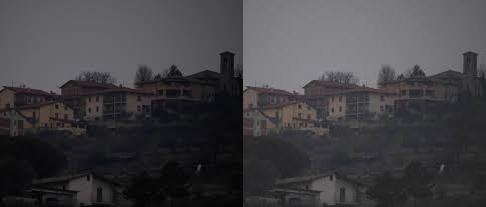

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np

print(' Mengubah tingkat kecerahan citra ')
print('.................................')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

Inverse Citra
-----------------------------------


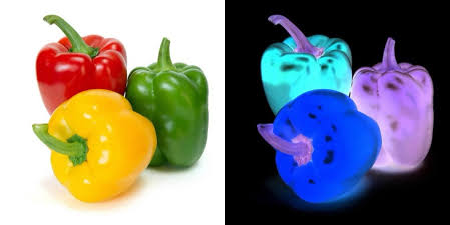

In [ ]:
print('Inverse Citra')
print('-----------------------------------')

# sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
inverse_image = np.zeros(original.shape, original.dtype)

# akses per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

# cara simple tanpa for loop (opsional, hasil setara)
# inverse_image = 255 - original

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

Mengubah kontras dan tingkat kecerahan citra
-----------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


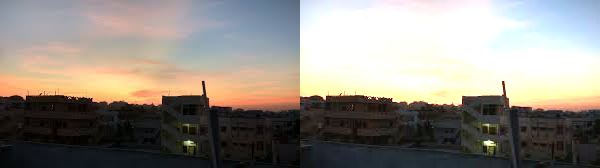

In [ ]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/sunset.jpg')
contrast_image = np.zeros(original.shape, original.dtype)

# akses per piksel, np.clip digunakan untuk truncate (nilai dibatasi 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            contrast_image[y, x, c] = np.clip(contrast * original[y, x, c] + brightness, 0, 255)

# cara simple tanpa for loop
# contrast_image = cv.convertScaleAbs(original, alpha=contrast, beta=brightness)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)


Mengubah tingkat kecerahan citra dengan Transformasi Log
-----------------------------------------------------
Masukkan nilai kecerahan: 50


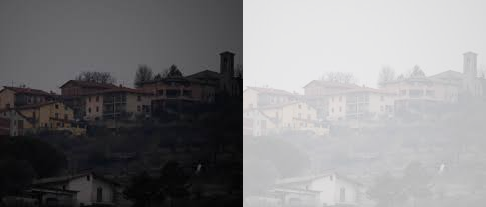

In [ ]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('-----------------------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/houses.jpg')
log_image = np.zeros(original.shape, original.dtype)

# konstanta c agar output tetap dalam rentang 0-255
c = 255 / np.log(1 + 255)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for ch in range(original.shape[2]):
            r = int(original[y, x, ch]) + brightness
            s = c * np.log(1 + r)
            log_image[y, x, ch] = np.clip(s, 0, 255)

final_frame = cv.hconcat((original, log_image))
cv2_imshow(final_frame)


In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')  # format BGR (OpenCV)
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

h, w = original.shape[:2]
gray_avg = np.zeros((h, w), dtype=np.uint8)
gray_lightness = np.zeros((h, w), dtype=np.uint8)
gray_luminance = np.zeros((h, w), dtype=np.uint8)

for y in range(h):
    for x in range(w):
        b, g, r = original[y, x]
        r, g, b = int(r), int(g), int(b)
        gray_avg[y, x] = np.clip((r + g + b) / 3, 0, 255)
        gray_lightness[y, x] = np.clip((max(r, g, b) + min(r, g, b)) / 2, 0, 255)
        gray_luminance[y, x] = np.clip(0.21 * r + 0.72 * g + 0.07 * b, 0, 255)


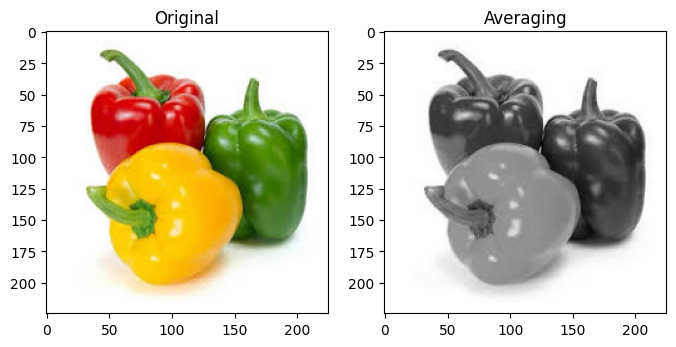

In [ ]:
import matplotlib.pyplot as plt

# a. Averaging
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(original_rgb); axs[0].set_title('Original')
axs[1].imshow(gray_avg, cmap='gray'); axs[1].set_title('Averaging')
plt.show()

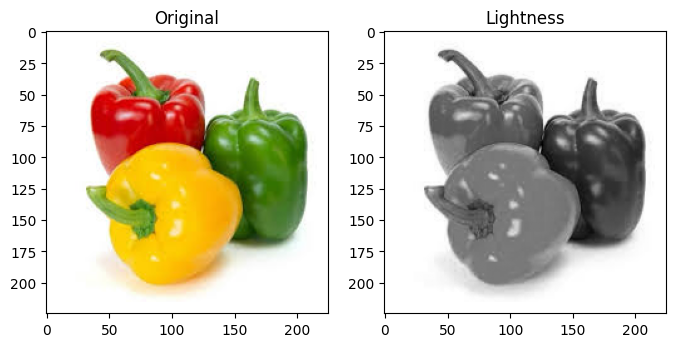

In [ ]:
# b. Lightness
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(original_rgb); axs[0].set_title('Original')
axs[1].imshow(gray_lightness, cmap='gray'); axs[1].set_title('Lightness')
plt.show()


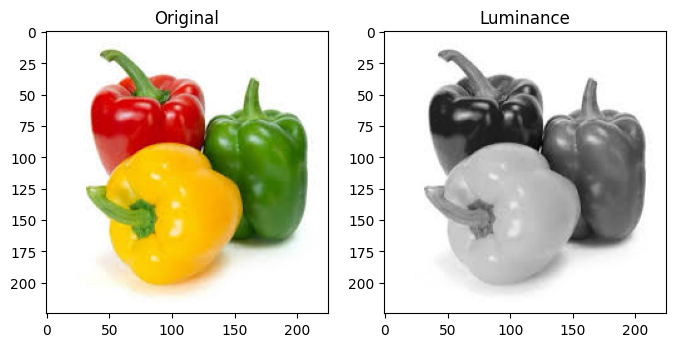

In [ ]:
# c. Luminance
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(original_rgb); axs[0].set_title('Original')
axs[1].imshow(gray_luminance, cmap='gray'); axs[1].set_title('Luminance')
plt.show()


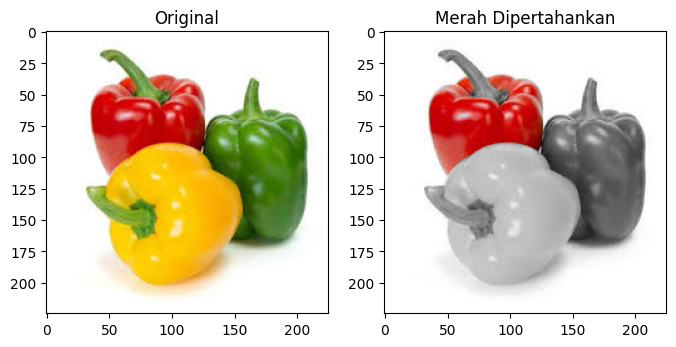

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg')
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# rentang warna merah pada HSV (merah berada di dua ujung hue)
lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
red_mask = cv.bitwise_or(mask1, mask2)

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# operasi AND untuk mengambil area merah dari citra asli
red_part = cv.bitwise_and(original, original, mask=red_mask)
# operasi AND dengan NOT mask untuk mengambil area selain merah dari citra grayscale
gray_part = cv.bitwise_and(gray_bgr, gray_bgr, mask=cv.bitwise_not(red_mask))

# gabungkan dengan operasi OR
result = cv.bitwise_or(red_part, gray_part)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); axs[0].set_title('Original')
axs[1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB)); axs[1].set_title('Merah Dipertahankan')
plt.show()


 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


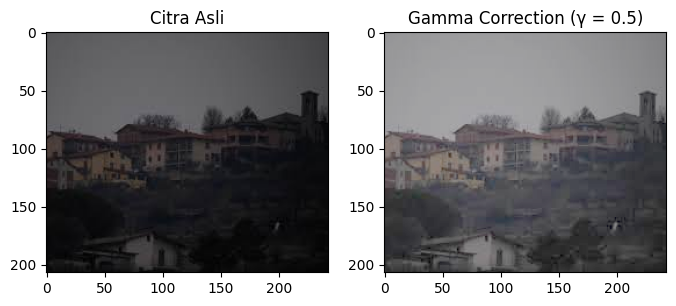

In [ ]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/houses.jpg')
gamma_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            gamma_image[y, x, c] = np.clip(255 * ((original[y, x, c] / 255) ** gamma), 0, 255)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); axs[0].set_title('Citra Asli')
axs[1].imshow(cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)); axs[1].set_title(f'Gamma Correction (γ = {gamma})')
plt.show()


Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


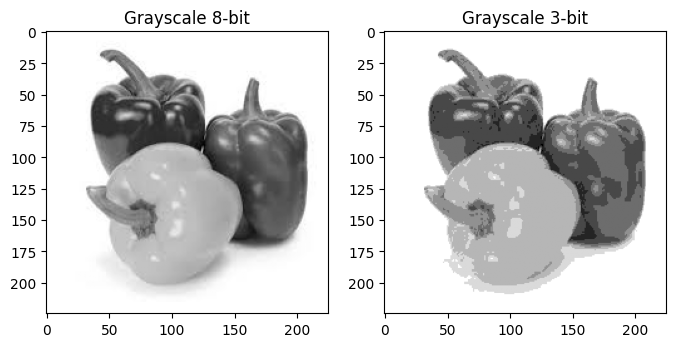

In [ ]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, not a number')

level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/PCVK/peppers.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        depth_image[y, x] = round(original[y, x] / level) * level

print(f'Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {pow(2, bit_depth)}')

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(original, cmap='gray'); axs[0].set_title('Grayscale 8-bit')
axs[1].imshow(depth_image, cmap='gray'); axs[1].set_title(f'Grayscale {bit_depth}-bit')
plt.show()


In [ ]:
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:  # MSE 0 maka tidak ada noise sama sekali, sehingga PSNR tidak memiliki arti
        return 100
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

def average_denoise(images, n):
    subset = images[:n]
    stacked = np.stack(subset, axis=0).astype(np.float64)
    avg = np.mean(stacked, axis=0)
    return np.clip(avg, 0, 255).astype(np.uint8)


In [ ]:
import glob

original = cv.imread('/content/drive/MyDrive/PCVK/noises/1.jpg')

cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

print(f'Jumlah citra noise yang terbaca: {len(cv_img)}')

Jumlah citra noise yang terbaca: 100


Jumlah citra di-average:  10 -> PSNR: 22.82 dB


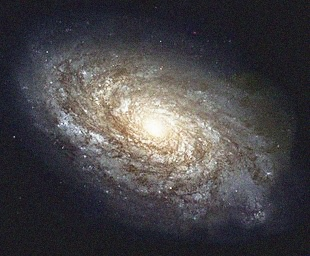

Jumlah citra di-average:  20 -> PSNR: 23.03 dB


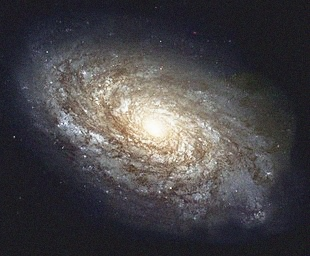

Jumlah citra di-average:  40 -> PSNR: 23.34 dB


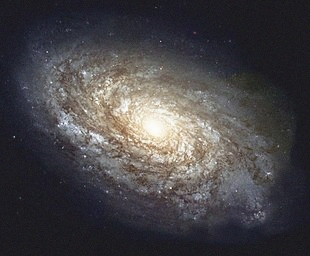

Jumlah citra di-average:  80 -> PSNR: 23.30 dB


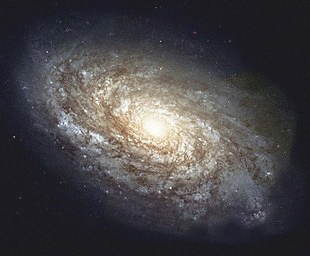

Jumlah citra di-average: 100 -> PSNR: 23.28 dB


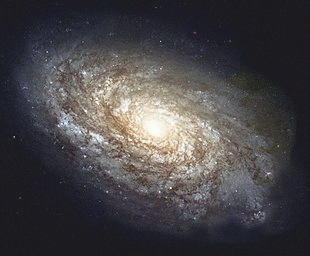

In [ ]:
jumlah_list = [10, 20, 40, 80, 100]
hasil_psnr = {}

for n in jumlah_list:
    denoised = average_denoise(cv_img, n)
    psnr_value = PSNR(original, denoised)
    hasil_psnr[n] = psnr_value
    print(f'Jumlah citra di-average: {n:>3} -> PSNR: {psnr_value:.2f} dB')
    cv2_imshow(denoised)


In [ ]:
import cv2 as cv
import numpy as np

original = cv.imread('/content/drive/MyDrive/PCVK/masking.jpg')
h, w = original.shape[:2]

# Membuat dua region (set) A dan B yang saling bertumpang tindih, sesuai ilustrasi
maskA = np.zeros((h, w), dtype=np.uint8)
maskB = np.zeros((h, w), dtype=np.uint8)

cv.circle(maskA, (int(w*0.35), int(h*0.5)), int(min(h, w)*0.18), 255, -1)
cv.circle(maskB, (int(w*0.55), int(h*0.5)), int(min(h, w)*0.18), 255, -1)

not_A     = cv.bitwise_not(maskA)
and_AB    = cv.bitwise_and(maskA, maskB)
or_AB     = cv.bitwise_or(maskA, maskB)
nand_AB   = cv.bitwise_not(and_AB)
xor_AB    = cv.bitwise_xor(maskA, maskB)

operator_masks = {
    'NOT (Komplemen)': not_A,
    'OR (Atau)': or_AB,
    'AND (Dan)': and_AB,
    'NAND (Not And)': nand_AB,
    'XOR (Exclusive Or)': xor_AB,
}

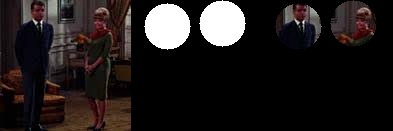

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/masking.jpg')
h, w = original.shape[:2]

mask = np.zeros((h, w), dtype=np.uint8)

center_pria   = (int(w * 0.28), int(h * 0.20))
center_wanita = (int(w * 0.70), int(h * 0.18))   # digeser lebih ke kanan
radius = int(min(h, w) * 0.18)

cv.circle(mask, center_pria, radius, 255, -1)
cv.circle(mask, center_wanita, radius, 255, -1)

masked_image = cv.bitwise_and(original, original, mask=mask)
mask_bgr = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

final_frame = cv.hconcat((original, mask_bgr, masked_image))
cv2_imshow(final_frame)

NOT (Komplemen)


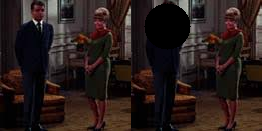

------------------------------------------------------------
OR (Atau)


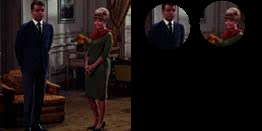

------------------------------------------------------------
AND (Dan)


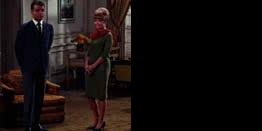

------------------------------------------------------------
NAND (Not And)


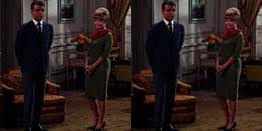

------------------------------------------------------------
XOR (Exclusive Or)


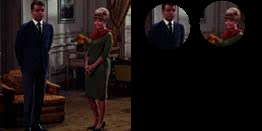

------------------------------------------------------------


In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/masking.jpg')
h, w = original.shape[:2]

# Dua region (set) A dan B sesuai posisi wajah yang sudah disesuaikan
maskA = np.zeros((h, w), dtype=np.uint8)
maskB = np.zeros((h, w), dtype=np.uint8)

center_pria   = (int(w * 0.28), int(h * 0.20))
center_wanita = (int(w * 0.70), int(h * 0.18))
radius = int(min(h, w) * 0.18)

cv.circle(maskA, center_pria, radius, 255, -1)
cv.circle(maskB, center_wanita, radius, 255, -1)

# Operator logika
not_A   = cv.bitwise_not(maskA)
or_AB   = cv.bitwise_or(maskA, maskB)
and_AB  = cv.bitwise_and(maskA, maskB)
nand_AB = cv.bitwise_not(and_AB)
xor_AB  = cv.bitwise_xor(maskA, maskB)

operators = {
    'NOT (Komplemen)': not_A,
    'OR (Atau)': or_AB,
    'AND (Dan)': and_AB,
    'NAND (Not And)': nand_AB,
    'XOR (Exclusive Or)': xor_AB,
}

# Tampilkan tiap baris: Image Input | Image Output
for name, m in operators.items():
    result = cv.bitwise_and(original, original, mask=m)
    print(name)
    final_frame = cv.hconcat((original, result))
    cv2_imshow(final_frame)
    print('-' * 60)

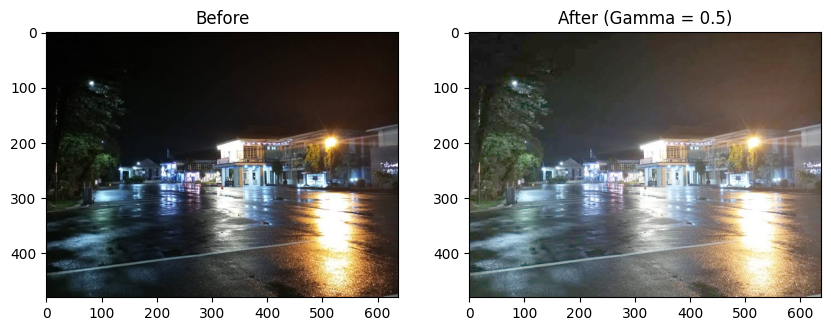

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/malam.jpg')

gamma = 0.5
gamma_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            gamma_image[y, x, c] = np.clip(255 * ((original[y, x, c] / 255) ** gamma), 0, 255)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); axs[0].set_title('Before')
axs[1].imshow(cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)); axs[1].set_title(f'After (Gamma = {gamma})')
plt.show()

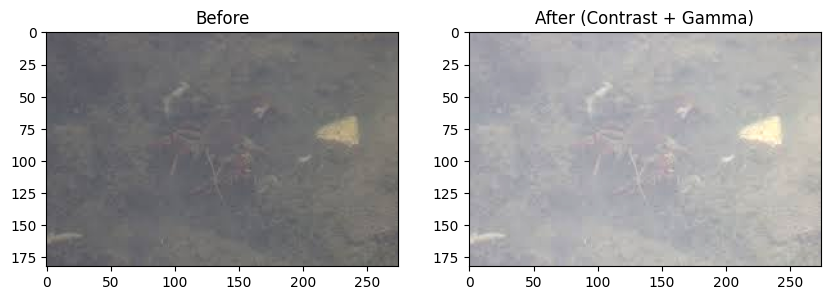

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/crayfish.jpg')

# Tahap 1: Transformasi Contrast -> g(x,y) = a*f(x,y) + b
contrast = 1.4
brightness = 15
contrast_image = np.clip(contrast * original.astype(np.float64) + brightness, 0, 255).astype(np.uint8)

# Tahap 2: Gamma Correction -> I' = 255 * (I/255)^gamma
gamma = 0.8
final_image = np.clip(255 * ((contrast_image.astype(np.float64) / 255) ** gamma), 0, 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)); axs[0].set_title('Before')
axs[1].imshow(cv.cvtColor(final_image, cv.COLOR_BGR2RGB)); axs[1].set_title('After (Contrast + Gamma)')
plt.show()
